In [195]:
import pandas as pd
import numpy as np

df = pd.read_csv("CO2_Emissions_Sample.csv")

#Data Cleaning

#fill in missing values
#interpolate within each country
df['GDP'] = (
    df.groupby('Country')['GDP']
      .transform(lambda x: x.interpolate(method='linear'))
)

df['CO2_Emissions'] = (
    df.groupby('Country')['CO2_Emissions']
      .transform(lambda x: x.interpolate(method='linear'))
)

df['Methane_Emissions'] = (
    df.groupby('Country')['Methane_Emissions']
      .transform(lambda x: x.interpolate(method='linear'))
)

#fill other missing values
cols = ['GDP', 'CO2_Emissions', 'Methane_Emissions']

for col in cols:
    df[col] = (
        df.groupby('Country')[col]
          .transform(lambda x: x.interpolate(method='linear')
                              .fillna(x.median()))
    )

#save cleaned dataset
df.to_csv("CO2_Emissions_Sample_Cleaned.csv", index=False) 

df.head()

,Country,Continent,Year,CO2_Emissions,Methane_Emissions,Nitrous_Emissions,GDP,Population
0,Canada,North America,2000,7750.862683,1053.030592,371.225407,734.472170,3.510898e+07
1,Canada,North America,2001,7955.423607,1023.118633,199.876401,17204.341086,7.396990e+07
2,Canada,North America,2002,8690.632912,994.091186,459.825424,37012.640134,1.296462e+07
3,Canada,North America,2003,8007.548172,489.361214,460.923247,29251.111335,2.075688e+07
4,Canada,North America,2004,7324.463432,1077.207390,408.154588,23575.082668,1.239332e+07


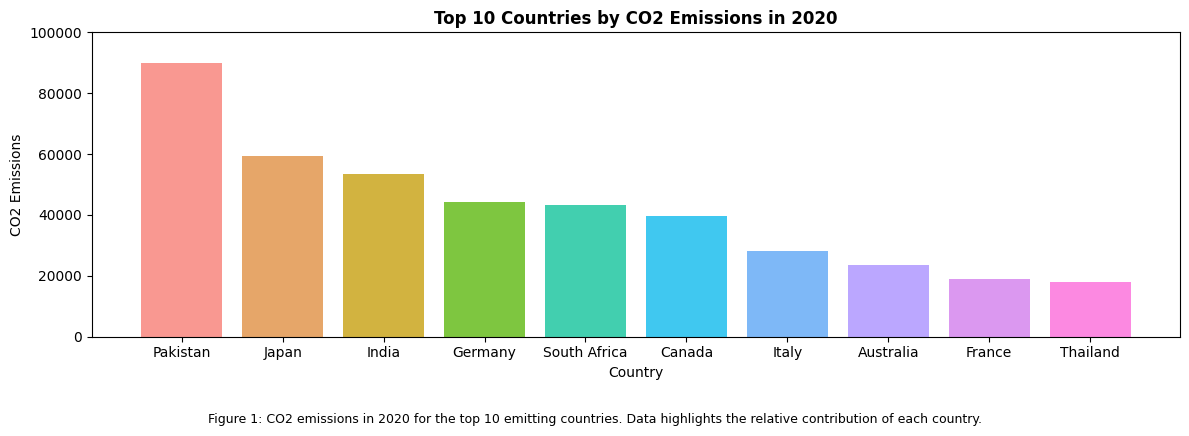

In [177]:
#Part A
import matplotlib.pyplot as plt

#Bar Chart - Top 10 Countries by CO2 Emissions
df_2020 = df[df['Year'] == 2020]
top10_2020 = (
    df_2020
    .sort_values(by="CO2_Emissions", ascending=False)
    .head(10)
)

top10_2020[['Country', 'CO2_Emissions']]

# qualitative colour scale to differentiate provinces (discrete categories)
colours = ['#F8766D', '#DE8837', '#C49A00', '#53B400', 
           '#02C094', '#00B6EB', '#53A0F5', '#A58AFF', '#D076EB', '#FB61D7']

plt.figure(figsize=(12,4))
plt.bar(top10_2020['Country'], top10_2020['CO2_Emissions'], color=colours, alpha=0.75)
plt.xlabel("Country")
plt.ylabel("CO2 Emissions")
plt.ylim(0,100000)
plt.title("Top 10 Countries by CO2 Emissions in 2020", fontweight='bold')
plt.tight_layout()

# add caption
plt.figtext(0.5, -0.07, 
            "Figure 1: CO2 emissions in 2020 for the top 10 emitting countries. Data highlights the relative contribution of each country.",
            wrap=True, horizontalalignment='center', fontsize=9)

plt.show()


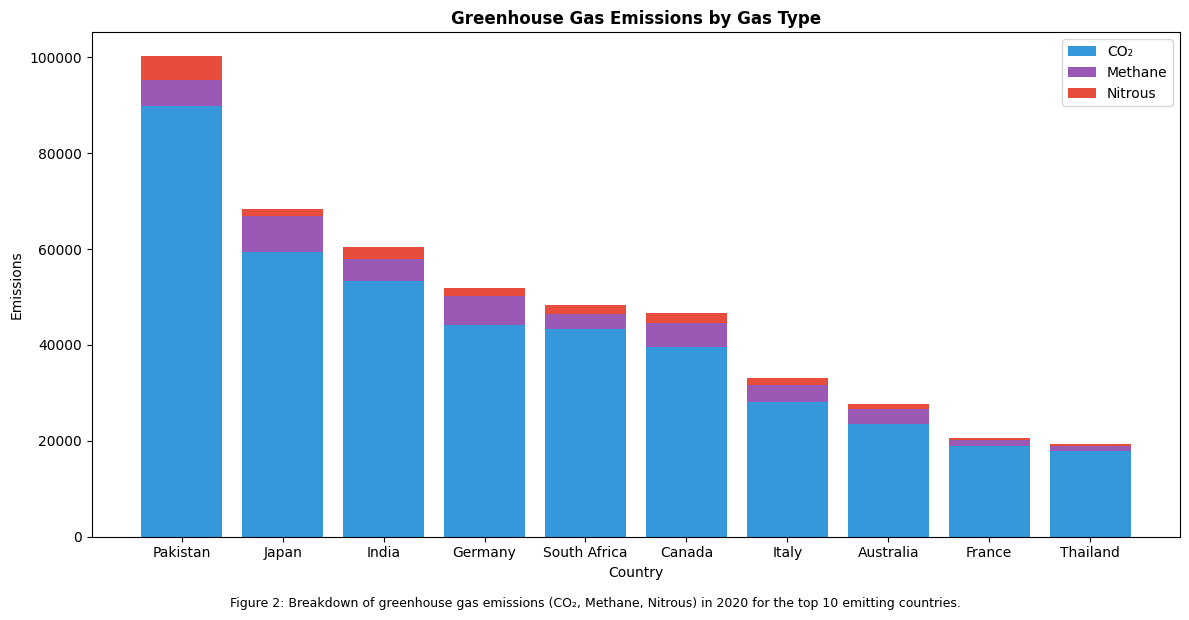

In [178]:
#Stacked Bar Chart - Same Countries with CO2, Methane and Nitrous Emissions

top_countries = top10_2020['Country']

stacked_2020 = df[
    (df['Year'] == 2020) &
    (df['Country'].isin(top_countries))
]

stacked_2020 = stacked_2020.set_index('Country').loc[top_countries].reset_index()

emission_colors = {
    'CO2_Emissions': '#3498db',     
    'Methane_Emissions': '#9b59b6',  
    'Nitrous_Emissions': '#e74c3c'   
}

plt.figure(figsize=(12,6))

plt.bar(
    stacked_2020['Country'],
    stacked_2020['CO2_Emissions'],
    label='CO₂',
    color=emission_colors['CO2_Emissions']
)

plt.bar(
    stacked_2020['Country'],
    stacked_2020['Methane_Emissions'],
    bottom=stacked_2020['CO2_Emissions'],
    label='Methane',
    color=emission_colors['Methane_Emissions']
)

plt.bar(
    stacked_2020['Country'],
    stacked_2020['Nitrous_Emissions'],
    bottom=stacked_2020['CO2_Emissions'] + stacked_2020['Methane_Emissions'],
    label='Nitrous',
    color=emission_colors['Nitrous_Emissions']
)

plt.xlabel("Country")
plt.ylabel("Emissions")
plt.title("Greenhouse Gas Emissions by Gas Type", fontweight='bold')
plt.legend()
plt.tight_layout()

# add caption
plt.figtext(0.5, -0.02, 
            "Figure 2: Breakdown of greenhouse gas emissions (CO₂, Methane, Nitrous) in 2020 for the top 10 emitting countries.",
            wrap=True, horizontalalignment='center', fontsize=9)
plt.show()

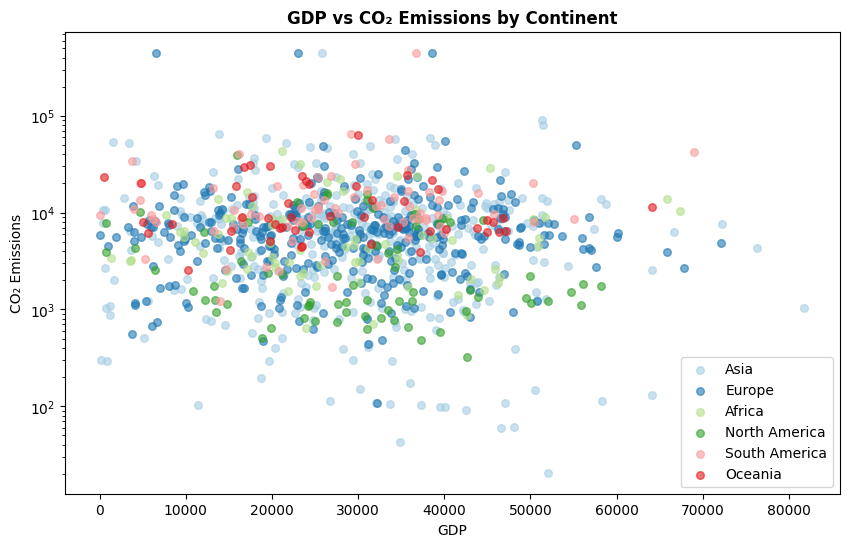

In [179]:
#Part B

#scatter plot - GDP vs CO2 emissions by continent

continent_colors = {
    'Asia': '#a6cee3',
    'Europe': '#1f78b4',
    'Africa': '#b2df8a',
    'North America': '#33a02c',
    'South America': '#fb9a99',
    'Oceania': '#e31a1c'
}

plt.figure(figsize=(10,6))

for continent, color in continent_colors.items():
    subset = df[df['Continent'] == continent]
    plt.scatter(
        subset['GDP'], 
        subset['CO2_Emissions'], 
        label=continent, 
        color=color,
        s=30,
        alpha=0.6)

plt.xlabel("GDP")
plt.ylabel("CO₂ Emissions")

plt.yscale('log')
plt.title("GDP vs CO₂ Emissions by Continent", fontweight='bold')
plt.legend()
plt.show()

While a few high-emission countries appear as outliers, they reflect real-world structural differences in industrial output and population size. Therefore, a logarithmic scale was applied instead of removing these values.

The majority of the dots are between 1000 and 10,000 C02 emissions with scattered GDP. Asia has the most scattered dots showing a great dispersion in C02 emissions. This reflects the contrast between highly industrialized economies and developing nations with lower emission levels. In contrast, other continents show more clustered distributions, indicating relatively similar emission scales within those regions.

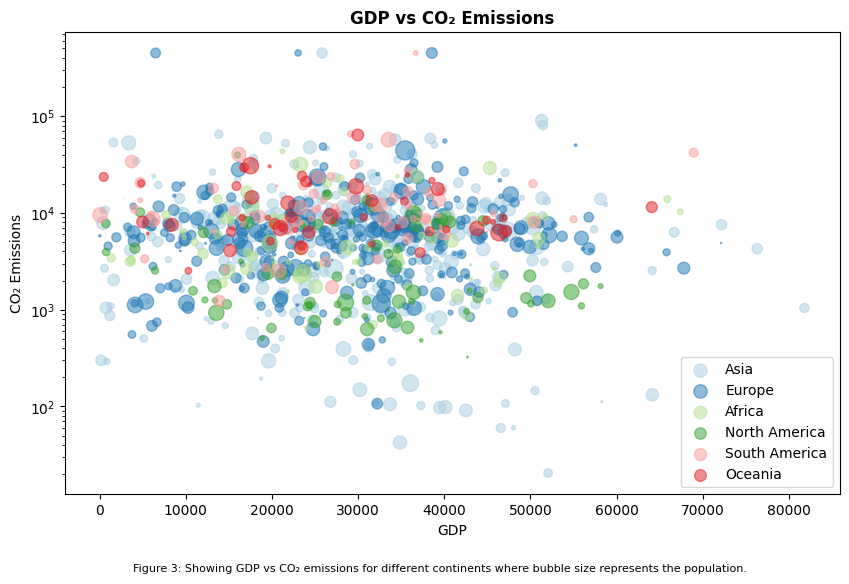

In [180]:
#bubble chart - GDP vs CO2 emissions, bubble size = population

plt.figure(figsize=(10,6))

for continent, color in continent_colors.items():
    subset = df[df['Continent'] == continent]
    plt.scatter(
        subset['GDP'],
        subset['CO2_Emissions'],
        s=subset['Population'] / 1_000_000,
        label=continent,
        color=color,
        alpha=0.5,
    )

plt.xlabel("GDP")
plt.ylabel("CO₂ Emissions")
plt.yscale('log')
plt.title("GDP vs CO₂ Emissions", fontweight='bold')
plt.figtext(0.5, -0.02, 
            "Figure 3: Showing GDP vs CO₂ emissions for different continents where bubble size represents the population.",
            wrap=True, horizontalalignment='center', fontsize=8)
plt.legend()
plt.show()

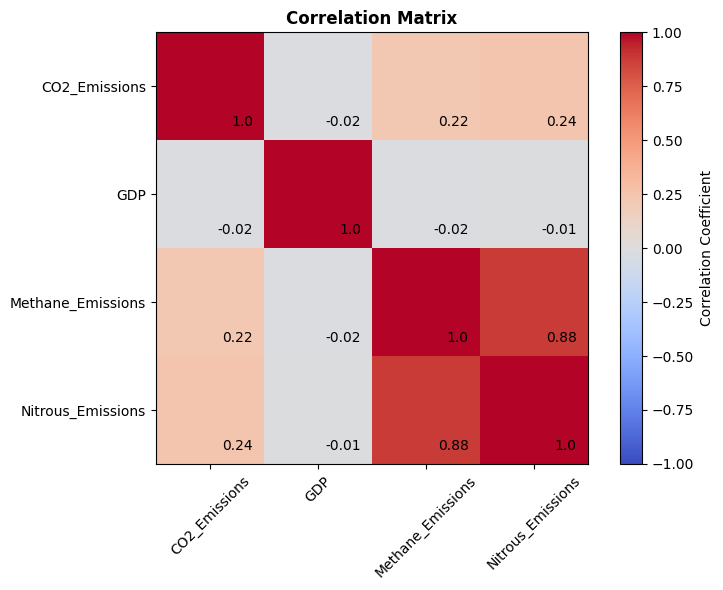

In [181]:
#correlogram - CO₂, GDP, Methane, Nitrous

corr_matrix = df[['CO2_Emissions', 
                  'GDP', 
                  'Methane_Emissions', 
                  'Nitrous_Emissions']].corr()

plt.figure(figsize=(8,6))

plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation Coefficient')

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        plt.text(j+0.4, i+0.4, round(corr_matrix.iloc[i, j], 2),
                 ha='right', va='bottom', color='black')

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Correlation Matrix", fontweight = 'bold')
plt.tight_layout()
plt.show()

There is a strong positive correlation between nitrous and methane emissions (r = 0.88). In contrast, correlations between the remaining variables are weak (around r ≈ 0.2), suggesting limited linear association among them.

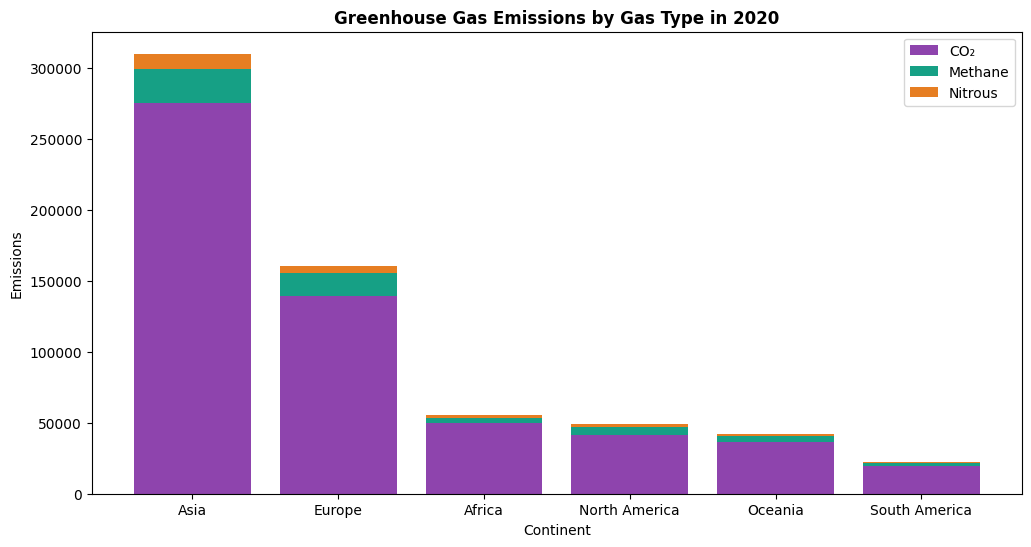

In [182]:
#Part C

#stacked bar chart
continents_2020 = df[df['Year'] == 2020]

continents_2020 = (
    continents_2020
    .groupby('Continent')[['CO2_Emissions', 
                           'Methane_Emissions', 
                           'Nitrous_Emissions']]
    .sum()
    .sort_values(by="CO2_Emissions", ascending=False)
    .reset_index()
)

#use larger difference colors to see smaller values
emission_colors_alt = {
    'CO2_Emissions': '#8e44ad',     
    'Methane_Emissions': '#16a085',
    'Nitrous_Emissions': '#e67e22'   
}

plt.figure(figsize=(12,6))

plt.bar(
    continents_2020['Continent'],
    continents_2020['CO2_Emissions'],
    label='CO₂',
    color=emission_colors_alt['CO2_Emissions']
)

plt.bar(
    continents_2020['Continent'],
    continents_2020['Methane_Emissions'],
    bottom=continents_2020['CO2_Emissions'],
    label='Methane',
    color=emission_colors_alt['Methane_Emissions']
)

plt.bar(
    continents_2020['Continent'],
    continents_2020['Nitrous_Emissions'],
    bottom=continents_2020['CO2_Emissions'] + continents_2020['Methane_Emissions'],
    label='Nitrous',
    color=emission_colors_alt['Nitrous_Emissions']
)

plt.xlabel("Continent")
plt.ylabel("Emissions")
plt.title("Greenhouse Gas Emissions by Gas Type in 2020", fontweight='bold')
plt.legend()

plt.show()

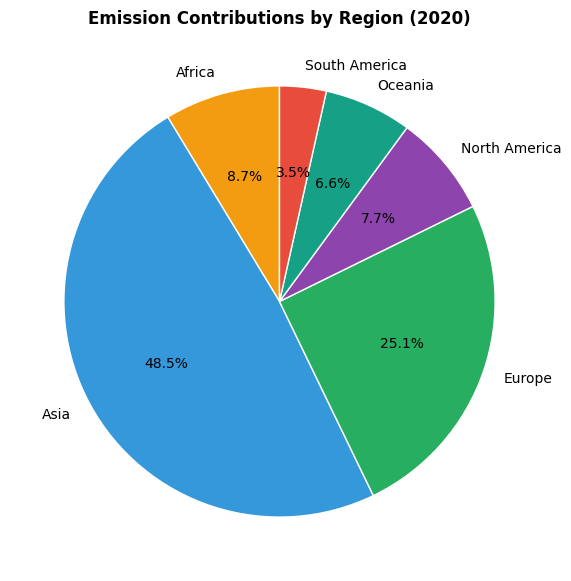

In [188]:
#pie chart - emission contributions by region

total_emissions = (
    df_2020
    .groupby('Continent')[['CO2_Emissions',
                           'Methane_Emissions',
                           'Nitrous_Emissions']]
    .sum()
    .sum(axis=1)
)

continent_colors = {
    'Africa': '#f39c12',         
    'Asia': '#3498db',             
    'Europe': '#27ae60',           
    'North America': '#8e44ad',    
    'South America': '#e74c3c',    
    'Oceania': '#16a085'           
}

plt.figure(figsize=(7,7))

colors = [continent_colors[continent] for continent in total_emissions.index]

plt.pie(
    total_emissions,
    labels=total_emissions.index,
    autopct='%1.1f%%',  
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'white'}
)

plt.title("Emission Contributions by Region (2020)", fontweight='bold')
plt.show()


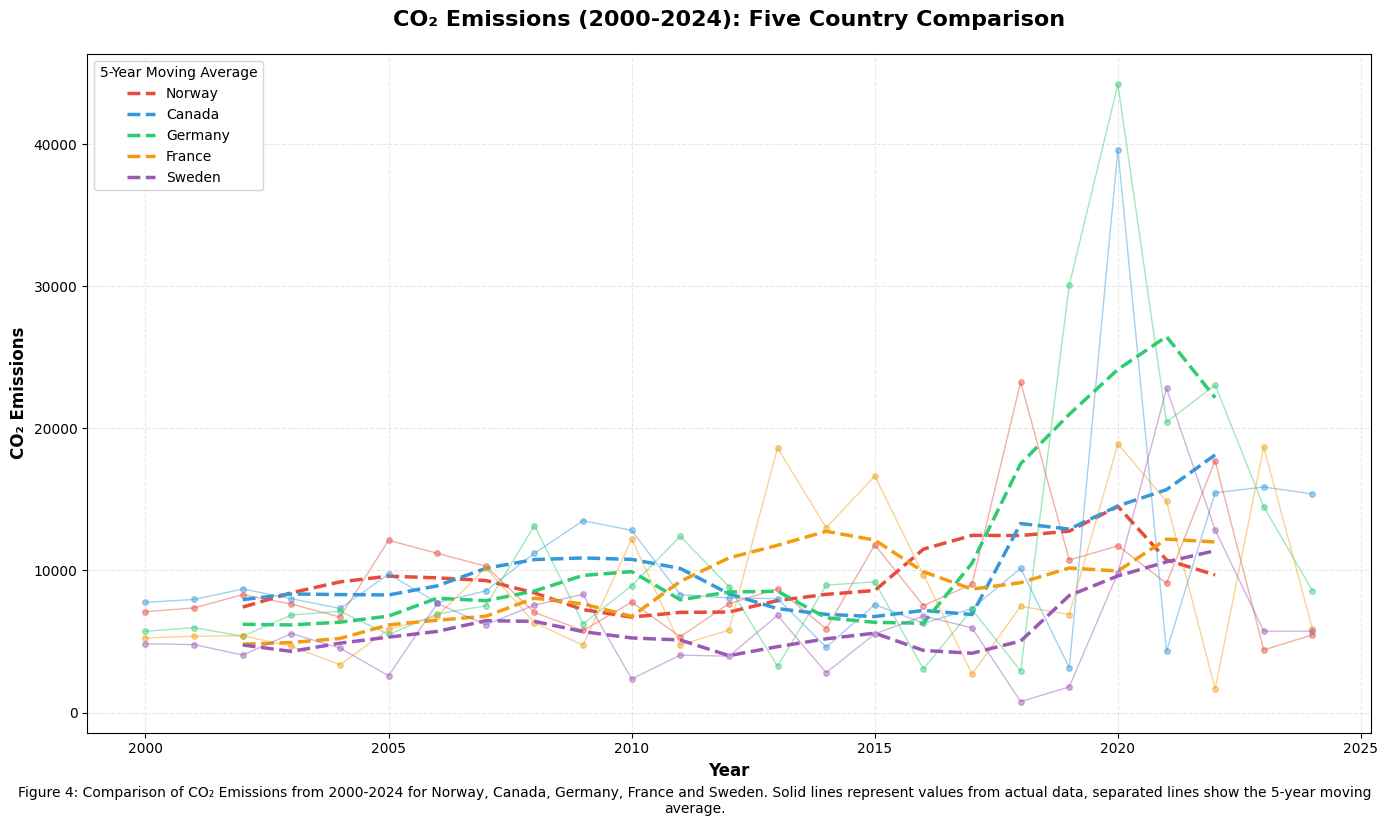

In [189]:
#Part D

#line chart - CO2 emissions from 2000-2024 for 5 selected countries
#Norway, Canada, Germany, France, Sweden 

selected_countries = ['Norway', 'Canada', 'Germany', 'France', 'Sweden']
df_filtered = df[df['Country'].isin(selected_countries)]
df_filtered = df_filtered[(df_filtered['Year'] >= 2000) & (df_filtered['Year'] <= 2024)]

df_filtered['MA_5year'] = df_filtered.groupby('Country')['CO2_Emissions'].transform(
    lambda x: x.rolling(window=5, center=True).mean()
)

colors = {
    'Norway': '#e74c3c',  
    'Canada': '#3498db',      
    'Germany': '#2ecc71',     
    'France': '#f39c12',      
    'Sweden': '#9b59b6'       
}

plt.figure(figsize=(14, 8))

for country in selected_countries:
    country_data = df_filtered[df_filtered['Country'] == country]
    
    plt.plot(country_data['Year'], country_data['CO2_Emissions'], 
             marker='o', markersize=4, alpha=0.45, linewidth=1,
             color=colors[country])
    
    plt.plot(country_data['Year'], country_data['MA_5year'], 
             linewidth=2.5, color=colors[country], linestyle='--',
             label=f'{country}')

plt.title('CO₂ Emissions (2000-2024): Five Country Comparison', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('CO₂ Emissions', fontsize=12, fontweight='bold')
plt.legend(title='5-Year Moving Average',
           loc='upper left')
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()

plt.figtext(0.5, -0.02, 
            "Figure 4: Comparison of CO₂ Emissions from 2000-2024 for Norway, Canada, Germany, France and Sweden. Solid lines represent values from actual data, separated lines show the 5-year moving average.",
            wrap=True, horizontalalignment='center', fontsize=10)

plt.show()

There is an overall increase in CO2 emissions since 2000 through around 2020 where the emissions peaked, followed by a decline in recent years. This  pattern suggests a potential shift in emissions policies or economic factors around 2020, likely due to COVID-19. The 4 countries (Norway, Canada, France and Sweden) have relatively similar emissions lying around 10,000 million tonnes throughout the period. Germany is the clear outlier having significantly higher moving average around 2020, being over 20,000 million tonnes.

The 5-year moving averages effectively smooth out the peaks to give a more overall trend  revealing steady growth from 2000 to peak years around 2020. However, because the moving average requires data from surrounding years, the most recent 2-3 years lack smoothed trend lines, limiting our ability to assess whether recent declines is a true decline or is temporary.

Explained variance PC1: 0.5515905941928868
Explained variance PC2: 0.35658532011497196
                        PC1       PC2
CO2_Emissions      0.565882 -0.205120
Methane_Emissions  0.550329  0.044641
Nitrous_Emissions  0.479950 -0.440606
GDP               -0.342936 -0.545299
Population         0.170171  0.681504


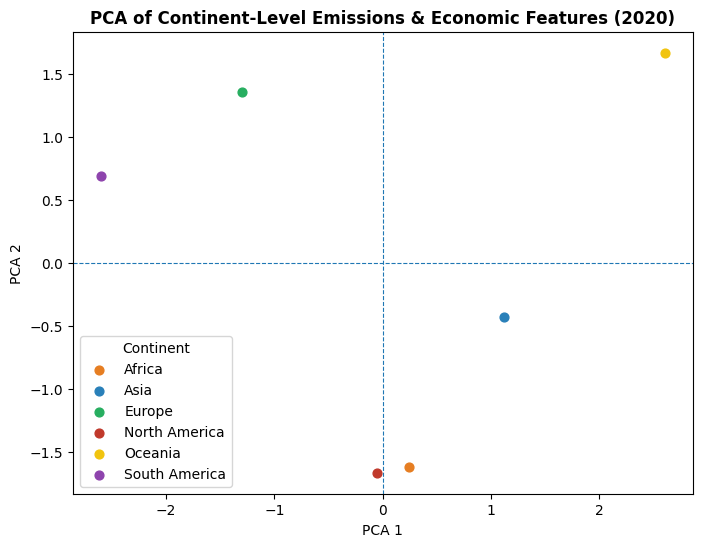

In [190]:
#Part E - PCA Representation

#1 - Data Aggregation

df_2020 = df[df['Year']==2020]
continent_features = (
    df_2020
    .groupby('Continent')[
        ['CO2_Emissions',
        'Methane_Emissions',
        'Nitrous_Emissions',
        'GDP',
        'Population']]
    .mean()
)

#2 - PCA Feature Extraction

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
scaled_data = scaler.fit_transform(continent_features)

pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_data)

explained_variance = pca.explained_variance_ratio_

print("Explained variance PC1:", explained_variance[0])
print("Explained variance PC2:", explained_variance[1])

loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=continent_features.columns
)

print(loadings)

#3 - Visualization

#change colors from previous for more differentiation from far away
continent_colors = {
    'Africa': '#e67e22',           
    'Asia': '#2980b9',             
    'Europe': '#27ae60',           
    'North America': '#c0392b',   
    'South America': '#8e44ad',    
    'Oceania': '#f1c40f'           
}

plt.figure(figsize=(8,6))

for i, continent in enumerate(continent_features.index):
    plt.scatter(
        pca_components[i, 0],
        pca_components[i, 1],
        color=continent_colors.get(continent, 'gray'),
        s=40,
        label=continent
    )

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("PCA of Continent-Level Emissions & Economic Features (2020)", fontweight = 'bold')
plt.axhline(0, linestyle='--', linewidth=0.8)
plt.axvline(0, linestyle='--', linewidth=0.8)
plt.legend(title='Continent')

plt.show()


## 4 - Interpretation

PCA is appropriate after aggregating by continent since it reduces the dimensionality of our 5 feature dataset. PCA reduces these correlated features into the 2 principal components that capture the variation in the dataset. This allows for clearer visual comparison between continents while avoiding redundancy among variables.

PC1 represents the primary dimension of variation across continents, reflecting overall economic development and emission scale. PC2 captures secondary structural differences, mainly capturing population scale and economic wealth.

South America: Demonstrates that South America has a low emission profile with moderate population and lower GDP. It maintains low industrial emissions possibly due to being less heavy industry based compared to other regions.

Europe: Shows relatively low emissions despite having developed economies, possibly due to cleaner technologies and better industrial practices. 

North America and Africa: Both sit at the bottom of the plot, indicating smaller populations. North America represents a wealthy, developed region with moderate emissions, while Africa reflects developing economies. Their similar PC1 values suggest comparable emission levels.

Oceania: Has the most extreme position on the plot showing the highest emissions combined with high population to GDP ratio. This likely reflects the region's resource-intensive industries. 

Asia: Asia has relatively high emissions across all categories due to the high PC1 value. This reflects Asia's role as a manufacturing hub. The moderate PC2 value indicates a balance between large populations and varying economic levels.